In [1]:
%run utilities_general.ipynb 
%run utilities_DIRKs_and_PIRKs.ipynb
load_standard_packages()
change_wordir()
import json
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import math

C:\Users\andre\AppData\Local\Temp\ipykernel_30420\1467589274.py:1: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.1)
  from scipy import interpolate
Could not find cannot import name 'dopri5' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'rodas' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'odassl' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find ODEPACK functions.
Could not find RADAR5
Could not find GLIMDA.


1.58.0


In [2]:
analysis = "DIRKs"

colors, colours = colourblind_palette("own")


#model = "with_dpsi"
model = "latest_dev"

m = load_model(model)


succesfully loaded latest_dev :D


In [3]:
# I like to have light as a derived variable
m.add_algebraic_module(module_name = "Light",
    function = lambda X, PFD: PFD, # X is not used
    compounds = ["PQ"], derived_compounds = ["L"], parameters = ['pfd'])

In [4]:
y0 = get_stst_y0(m)

# PIRK

In [5]:
s = Simulator(m)

ss_pfd = 100
pre_PIRK_time = 1
drk_pfd = 0 # 10 is already enough to accumulate ATP "in the dark" # drk = dark
pls_pfd = 2500 #1180           # pls = pulse
pls_t = 0.003 # seconds     # pulse time

#read: until <time> there is a pfd of <pfd>. then, ...
protocol = [(pre_PIRK_time, ss_pfd), (pls_t, pls_pfd), (0.0153, drk_pfd),
            (pls_t, pls_pfd), (0.0204, drk_pfd),
            (pls_t, pls_pfd), (0.0408, drk_pfd), (pls_t, pls_pfd),
            (0.0816, drk_pfd), (pls_t, pls_pfd), (0.1632, drk_pfd),
            (pls_t, pls_pfd), (0.3264, drk_pfd),(pls_t, pls_pfd), (0.3264, drk_pfd)
            ]

c, v = apply_protocol(s, protocol, use_tqdm = False, shift_time = False, output_in_ms = False) #must not be shifted for later anal

In [8]:
result = analyse_PIRK_from_simulation(c, protocol, input_is_in_ms=False,
                                      fit_timeframe=np.nan,
                                      visualize_fits="",
                                      protocol_time_is_accumulated=False,
                                      use_fixed_fit_wndw_len=True,
                                      collapse_rows_to_lists = True)

result

relaxation_periods:[(2, np.float64(1003.0), np.float64(1018.3)), (4, np.float64(1021.3), np.float64(1041.7)), (6, np.float64(1044.7), np.float64(1085.5)), (8, np.float64(1088.5), np.float64(1170.1)), (10, np.float64(1173.1), np.float64(1336.3)), (12, np.float64(1339.3), np.float64(1665.7)), (14, np.float64(1668.7), np.float64(1995.1000000000001))]
Using shortest protocol dark window: 15.299999999999955


,relaxation_index,start_time_ms,end_time_ms,duration,ECS_tot,ECS_b,ECS_Tau,ECS_rate,ECS_flux,ECS_Rsquared,P700_tot,P700_b,P700_Tau,P700_rate,P700_flux,P700_Rsquared
100,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]","[1003.0, 1021.3, 1044.7, 1088.5, 1173.1, 1339....","[1018.3, 1041.7, 1085.5, 1170.1, 1336.3, 1665....","[15.299999999999955, 20.40000000000009, 40.799...","[5.686180188339476, 7.588570880046786, 10.3708...","[8.367952161415346, 8.932056423331707, 9.41983...","[2.7339149085110397, 2.0772066816798676, 1.436...","[0.3657758318983767, 0.481415743950566, 0.6962...","[2.07986728871394, 3.653257495739325, 7.220781...","[0.80227548976431, 0.7525713635671694, 0.73689...","[0.6143515685902768, 0.6001694816459643, 0.599...","[0.002189738195798748, 0.0022220877820177797, ...","[1.2733964934953648, 1.2853023219757838, 1.297...","[0.7853013614440584, 0.7780270702870798, 0.770...","[0.4824511232192372, 0.4669481034807249, 0.461...","[0.9967833521269496, 0.9967031463135588, 0.996..."


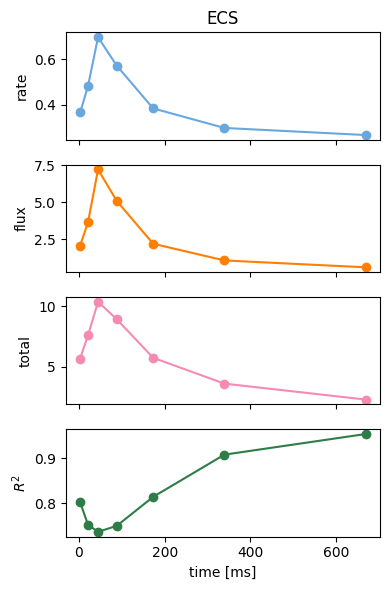

In [ ]:
df = result
x = np.array(df["start_time_ms"])-1000

rows = 4
fig, axs = plt.subplots(rows, figsize=(4, rows*1.5), sharex=True)

axs[0].set(title ="ECS")

# Row 0: Rate ------------------------------------------------
r = 0
axs[r].plot(x, df["ECS_rate"],# - min(df["ECS_rate"]),
               label="rate", color=colors[0], marker='o')
axs[r].set_ylabel("rate")

# Row 1: Flux ------------------------------------------------
r = 1 #row
axs[r].plot(x, df["ECS_flux"],# - min(df["ECS_flux"]),
               color=colors[1], marker='o')
axs[r].set_ylabel("flux")

r = 2
axs[r].plot(x, df["ECS_tot"],# - min(df["ECS_tot"]),
               label="tot", color=colors[3], marker='o')
axs[r].set_ylabel("total")

#Row 3: R² ------------------------------------------------
r = 3
axs[r].plot(x, df["ECS_Rsquared"], color=colors[2], marker='o')
axs[r].set_ylabel("$R^2$")

# Formatting
axs[-1].set_xlabel("time [ms]")
axs[-1].set_xlabel("time [ms]")

fig.tight_layout()


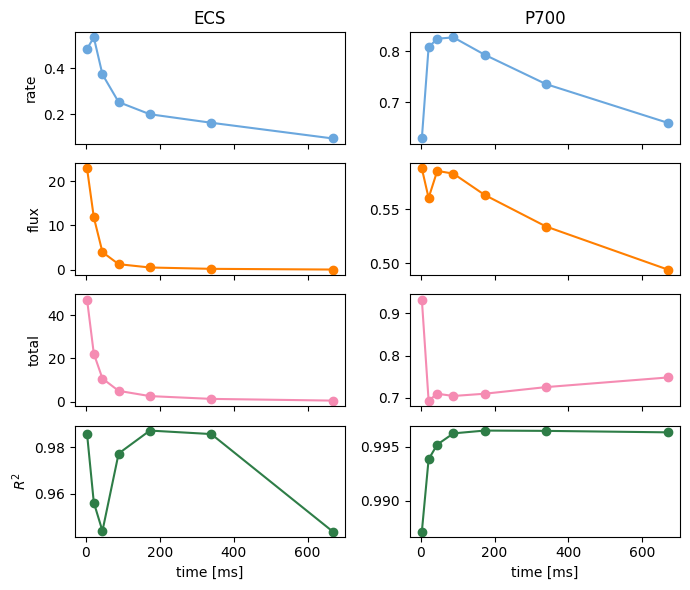

In [15]:
df = result
x = np.array(df["start_time_ms"])-1000

rows = 4
fig, axs = plt.subplots(rows, 2, figsize=(7, rows*1.5), sharex=True)

axs[0, 0].set(title ="ECS")
axs[0, 1].set(title ="P700")

# Row 0: Rate ------------------------------------------------
r = 0
axs[r, 0].plot(x, df["ECS_rate"],# - min(df["ECS_rate"]),
               label="rate", color=colors[0], marker='o')
axs[r, 1].plot(x, df["P700_rate"],
               label="rate", color=colors[0], marker='o')

axs[r, 0].set_ylabel("rate")
# axs[r, 0].set_yscale("log")
#axs[r, 1].set_yscale("log")

# Row 1: Flux ------------------------------------------------
r = 1 #row
axs[r, 0].plot(x, df["ECS_flux"],# - min(df["ECS_flux"]),
               color=colors[1], marker='o')
axs[r, 1].plot(x, df["P700_flux"],
               color=colors[1], marker='o')

axs[r, 0].set_ylabel("flux")
# axs[r, 0].set_yscale("log")
#axs[r, 1].set_yscale("log")

# Row 2: Tot + Amplitude (ECS_b on twin axis) ------------------------------------------------
r = 2
axs[r, 0].plot(x, df["ECS_tot"],# - min(df["ECS_tot"]),
               label="tot", color=colors[3], marker='o')
# ax2 = axs[r, 0].twinx()
# ax2.plot(x, df["ECS_b"], label="b", color=colors[5], marker='o')

axs[r, 0].set_ylabel("total")

# axs[r, 0].set_yscale("log")
#axs[r, 1].set_yscale("log")

axs[r, 1].plot(x, df["P700_tot"],
               color=colors[3], marker='o')
# ax4 = axs[r, 1].twinx()
# ax4.plot(x, df["P700_b"], color=colors[5], marker='o')

# ax4.set_ylabel("baseline")

# axs[r, 0].set_yscale("log")
#axs[r, 1].set_yscale("log")

#Row 3: R² ------------------------------------------------
r = 3
axs[r, 0].plot(x, df["ECS_Rsquared"], color=colors[2], marker='o')
axs[r, 1].plot(x, df["P700_Rsquared"], color=colors[2], marker='o')
axs[r, 0].set_ylabel("$R^2$")
# axs[r, 0].set_yscale("log")
# axs[r, 1].set_yscale("log")

# Formatting
axs[-1, 0].set_xlabel("time [ms]")
axs[-1, 1].set_xlabel("time [ms]")

fig.tight_layout()
